## Probability Distributions

Probability distributions are a collection of values that describe the likelihood of obtaining the possible values that a random variable can take. It's essentially a statistical function that shows the possible values and frequencies (or probabilities) for an event.

### Types of Probability Distributions

There are two main categories of probability distributions:

1. **Discrete Probability Distributions**: These deal with random variables that can only take on a finite or countably infinite number of values (e.g., number of heads in 10 coin flips).

2. **Continuous Probability Distributions**: These deal with random variables that can take on any value within a continuous range (e.g., height, weight, temperature).

### Probability Distribution Functions
A probability distribution function is a function that gives the probabilities of different possible outcomes for a random variable. There are two main types, each serving a different purpose for different types of data.

* **Probability Mass Function (PMF)**: For discrete random variables, this gives the probability of each specific value. It is denoted as $p(x) = P(X=x)$

* **Probability Density Function (PDF)**: For continuous random variables, this gives the relative likelihood of a value falling within a given range. It is also denoted as $p(x) = P(X=x)$. The PDF of a random variable X is defined as the derivative of its cumulative distribution function (CDF).

* **Cumulative Distribution Function (CDF)**: This is applicable to both discrete and continuous random variables. It's a function that gives the cumulative probability that a random variable is less than or equal to a certain value. It is defined as $F(x) = P(X \le x)$. In order to find the CDF ($F(x)$) in the discrete case, we sum up the values of the PMF for all outcomes less than or equal to $x$. In the continuous case, we use calculus to integrate the PDF over all values up to $x$.

This probability functions have two main properties. They are in the interval [0, 1], and the sum of all probabilities over all the values of the random variable is equal to 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Uniform Distribution

The uniform distribution is a type of probability distribution where all outcomes are equally likely. It can be discrete or continuous. Let's look at an example of rolling a die.

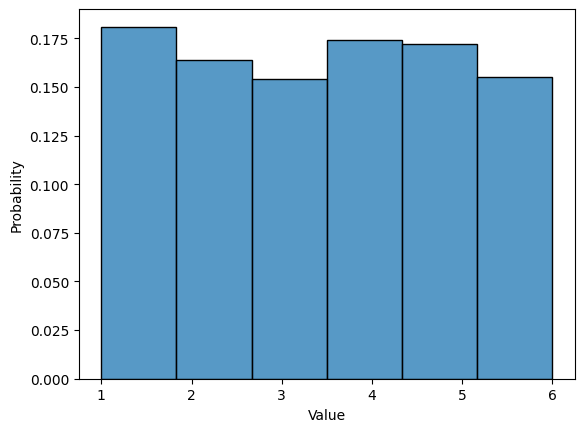

In [2]:
# Generate distribution of 1000 die rolls
np.random.seed(42)
x = np.random.randint(low=1, high=6 + 1, size=1000)

sns.histplot(x, bins=6, stat="probability")
plt.xlabel("Value");

Each time we roll the die, we have an equal chance of getting each face.

## Bernoulli Distribution

The Bernoulli distribution is a discrete distribution for a single trial that has only two possible outcomes: success (1) or failure (0). It's a simple, foundational distribution. For example, a single coin flip. Let's say heads is a "success" (1) and tails is a "failure" (0).

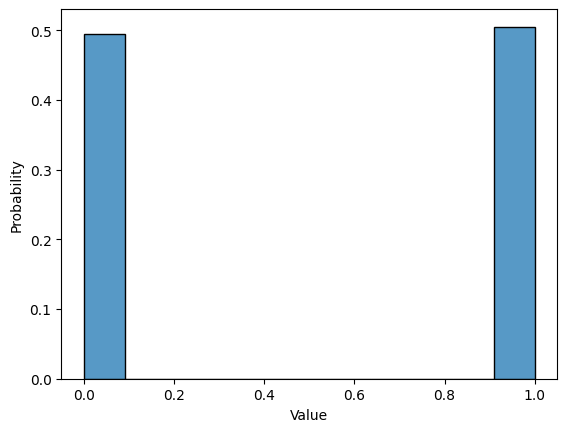

In [3]:
# Generate Bernoulli distributed data
x = np.random.binomial(n=1, p=0.5, size=1000)

sns.histplot(x, stat="probability")
plt.xlabel("Value");

## Binomial Distribution

The binomial distribution describes the number of successes in a fixed number of independent Bernoulli trials. It's defined by two parameters: the number of trials (n) and the probability of success (p). For example, flipping a fair coin 10 times and counting the number of heads. Here, n=10 and p=0.5.

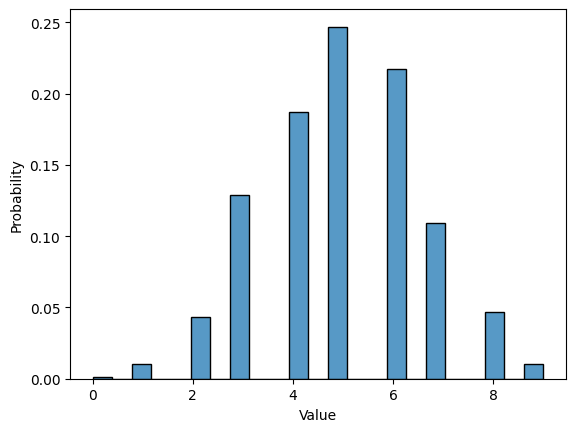

In [4]:
# Generate Binomial distributed data
x = np.random.binomial(n=10, p=0.5, size=1000)

sns.histplot(x, stat="probability")
plt.xlabel("Value");

## Normal Distribution

The normal distribution, also known as the Gaussian distribution or the "bell curve," is the most important continuous distribution in statistics. Many natural phenomena (e.g., height, blood pressure, IQ scores) follow this distribution. It's defined by its mean ($\mu$) and standard deviation ($\sigma$).

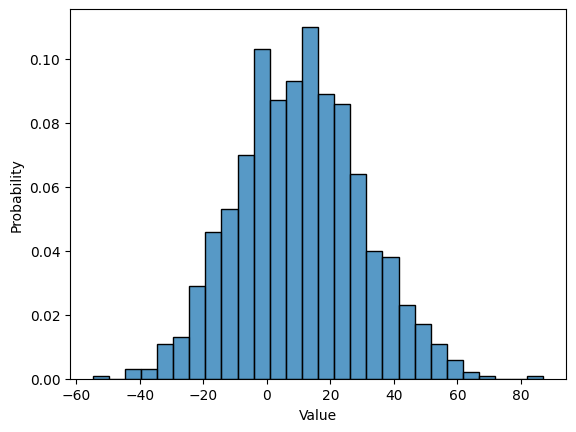

In [5]:
# Generate Normally distributed data
np.random.seed(42)
x = np.random.normal(10, 20, size=1000)

sns.histplot(x, stat="probability")
plt.xlabel("Value");

In [6]:
print("Mean:", np.mean(x))
print("Standard Deviation:", np.std(x))

Mean: 10.38664111644651
Standard Deviation: 19.574524154947085


## Standard Normal Distribution

The standard normal distribution is a special case of the normal distribution with a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1. Any normal distribution can be converted to a standard normal distribution using the z-score formula:

$$ z=\frac{(x−\mu)}{\sigma} $$

This process, known as standardization, allows us to compare data points from completely different datasets with different units, means, and standard deviations on a common scale.

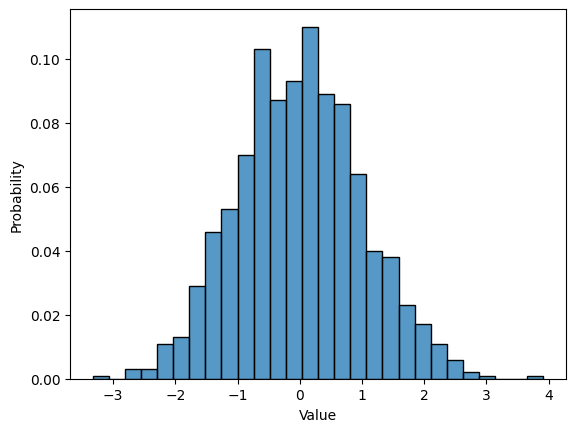

In [7]:
z_x = (x - np.mean(x))/np.std(x)

sns.histplot(z_x, stat="probability")
plt.xlabel("Value");

In [8]:
print("Mean:", np.mean(z_x).round(2))
print("Standard Deviation:", np.std(z_x))

Mean: -0.0
Standard Deviation: 1.0


A z-score tells us how many standard deviations away from the mean a data point is:

* A z-score of **1.0** means the data point is exactly one standard deviation above the mean.
* A z-score of **-2.0** means the data point is exactly two standard deviations below the mean.
* A z-score of **0.5** means the data point is half a standard deviation above the mean.

Given the mean and variance of a normal distribution, we can make the following statements:

* Around $68\%$ of all observations fall within one standard deviations around the mean ($\mu \pm \sigma$)
* Around $95\%$ of all observations fall within two standard deviations around the mean ($\mu \pm 2\sigma$)
* Around $99\%$ of all observations fall within three standard deviations aroud the mean ($\mu \pm 3\sigma$)

## Central Limit Thoerem

The Central Limit Theorem (CLT) is a fundamental concept in statistical analysis. It states that the sampling distribution of the sample mean will be approximately normal, regardless of the shape of the population distribution, as long as the sample size is large enough ($n \ge 30$).

The CLT implies that the mean of the sampling distribution of the sample means will be approximately equal to the population mean, and the distribution's shape will tend toward normality even if the population distribution itself is skewed or irregular. This allows us to apply methods that assume normality even when the original data isn't normally distributed. Let's see an example of drawing random samples from a uniform distribution.

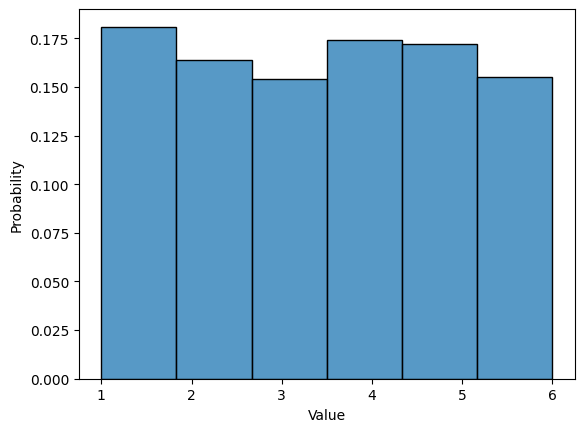

In [9]:
np.random.seed(42)
x = np.random.randint(low=1, high=6 + 1, size=1000)

sns.histplot(x, bins=6, stat="probability")
plt.xlabel("Value");

In [10]:
sample_size = 10
pop_size = len(x)
sample_means = []

for i in range(pop_size):
    samples = np.random.choice(x, sample_size, replace=False)
    sample_means.append(np.mean(samples))

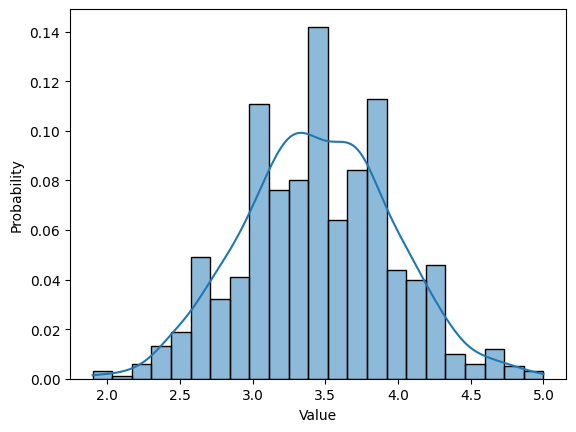

In [11]:
sns.histplot(sample_means, stat="probability", kde=True)
plt.xlabel("Value");

In [12]:
print("Population Mean:", np.mean(x))
print("Mean of Sample Means:", np.mean(sample_means))

Population Mean: 3.457
Mean of Sample Means: 3.4517


## Data Sampling Techniques

**Data sampling** is the process of selecting a subset of individuals or observations from a larger population. The goal is to make inferences about the entire population based on the smaller sample. Choosing the correct technique is crucial for ensuring the sample is **representative** and the results are **unbiased**.

Sampling methods fall into two main categories: **Probability Sampling** and **Non-Probability Sampling**.

### 1. Probability Sampling (Random Selection)

In probability sampling, every element in the population has a known, non-zero chance of being selected. This is the gold standard for statistical inference, as it allows researchers to generalize results to the population with quantifiable accuracy.

| Technique | Description | Best Used When |
| :--- | :--- | :--- |
| **Simple Random Sampling** | Every individual is chosen entirely by chance, and each individual has an equal probability of being included. *(e.g., drawing names out of a hat.)* | The population is homogeneous and readily available. |
| **Systematic Sampling** | Individuals are selected at regular intervals from an ordered list. *(e.g., selecting every 10th customer that walks into a store.)* | The population list is large and complete, and there is no pattern in the list that aligns with the sampling interval. |
| **Stratified Sampling** | The population is divided into homogeneous **subgroups (strata)** based on shared characteristics (e.g., gender, age, income). A random sample is then drawn from **each stratum**. | The population is heterogeneous, and the researcher wants to ensure specific subgroups are proportionally represented. |
| **Cluster Sampling** | The population is divided into separate groups called **clusters** (often based on geography, e.g., city blocks). A random sample of **clusters** is chosen, and **all** individuals within the selected clusters are sampled. | The population is geographically dispersed, and simple random sampling is too expensive or impractical. |


### 2. Non-Probability Sampling (Non-Random Selection)

In non-probability sampling, elements are selected based on the researcher's subjective judgment, convenience, or specific study criteria. This method is often easier and cheaper but introduces a high risk of **sampling bias**, making it difficult to generalize findings.

| Technique | Description | Best Used When |
| :--- | :--- | :--- |
| **Convenience Sampling** | Individuals who are most readily available to the researcher are selected. *(e.g., surveying students in your class.)* | Exploratory research is needed quickly, or cost is a major factor. |
| **Voluntary Response Sampling** | Individuals **self-select** to participate in the study, usually in response to an open invitation. *(e.g., online polls or call-in radio shows.)* | The researcher needs a fast and easy way to collect data, though bias (people with strong opinions are more likely to respond) is expected. |
| **Purposive Sampling** | The researcher selects individuals based on their own knowledge of the population and the study's specific goals. *(e.g., interviewing only subject matter experts.)* | The researcher needs to reach a targeted group of people with specific knowledge or characteristics. |
| **Quota Sampling** | The researcher sets **quotas** (non-randomly) for the sample based on certain characteristics (e.g., 50% male, 50% female) and selects individuals until the quota is filled. | The researcher wants a non-random sample that reflects key population proportions without the effort of random stratification. |

## Hypothesis Testing

Hypothesis testing is a statistical method used to make decisions about a population based on sample data. It's a formal procedure for investigating our ideas about the world using statistics. For example, we might ask the question "Is the average height of men in a city different from the national average?" We can't measure every man, so we take a sample and use hypothesis testing to draw a conclusion.

### Null and Alternative Hypothesis

Every hypothesis test has two competing hypotheses:

* **Null Hypothesis ($H_0$)**: This is the default statement or the status quo. It assumes there's no effect, no difference, or no relationship between the variables being tested. We assume the null hypothesis is true until we have enough evidence to prove otherwise.

    Example: The average commute time for employees is equal to 30 minutes.

* **Alternative Hypothesis ($H_a$ or $H_1$)**: This is the claim we are trying to find evidence for. It states that there is an effect, a difference, or a relationship.

    Example: The average commute time for employees is not equal to 30 minutes.

### The Process of Hypothesis Testing
Here's a step-by-step guide on how to perform a hypothesis test:

1. **State the Hypotheses**: Clearly define your null (H_0) and alternative (H_a) hypotheses.

2. **Choose a Significance Level ($\alpha$)**: This is the threshold for rejecting the null hypothesis. A common value is $\alpha=0.05$.

3. **Choose the Right Test Statistic**: Select a statistical test appropriate for your data and hypothesis (e.g., Z-test, T-test, Chi-squared test).

4. **Calculate the Test Statistic and P-value**: Use your sample data to compute the test statistic and the corresponding p-value.

5. **Make a Decision**: Compare the p-value to the significance level ($\alpha$).

    * If p-value $\le\alpha$, you reject the null hypothesis. Your results are statistically significant.

    * If p-value $\gt\alpha$, you fail to reject the null hypothesis. There is not enough evidence to support the alternative hypothesis.

### Type I and Type II Error

There are two types of errors you can make in a hypothesis test:

* **Type I Error (False Positive)**: Rejecting the null hypothesis when it is actually true.

    Example: A court finds a defendant guilty when they are actually innocent.

* **Type II Error (False Negative)**: Failing to reject the null hypothesis when it is actually false.

    Example: A court finds a defendant not guilty when they are actually guilty.

| **Decision** | $H_0$ True | $H_0$ False |
| --- | --- | --- |
| Do not reject $H_0$ | Correct Decision | Type II Error |
| Reject $H_0$ (accept $H_A$) | Type I Error | Correct Decision |

### P-value and Significance level

* **P-value**: The p-value is the probability of obtaining test results at least as extreme as the observed results, assuming the null hypothesis is true. It quantifies the strength of evidence against the null hypothesis. A smaller p-value indicates stronger evidence to reject the null hypothesis.

* **Significance level ($\alpha$)**: The significance level is a pre-determined threshold for deciding when to reject the null hypothesis. Commonly set at 0.05 or 0.01, it represents the maximum probability of committing a Type I error—rejecting a true null hypothesis. If the p-value is less than or equal to $\alpha$, the result is considered statistically significant.


### Test Statistics

A test statistic is a number calculated from the sample data during a hypothesis test. Its value tells us how far your sample data is from the null hypothesis. Once the test statistic is calculated, it is then compared to its distribution to determine whether to reject or not reject the null hypothesis.

The four most common distributions for test statistics are as follows:

* The $t$-distribution ($t$-test)
* The standard normal distribution ($z$-test)

We'll cover them in detail later

### Types of Hypothesis Tests

The type of test depends on the alternative hypothesis:

* **Two-tailed Test**: Used when the alternative hypothesis is that the parameter is **not equal** to a specific value. You are looking for a difference in either direction (greater or less).

    $$ H_a: \mu \ne 30$$

    Example: A pharmaceutical company develops a new drug for high blood pressure and wants to know if it has any effect on blood pressure. They don't know if the drug will increase or decrease blood pressure, only that it might change it.

    - $H_0$: $\mu = \mu_0$ (The mean blood pressure of people on the new drug is equal to the population mean).

    - $H_a$: $\mu \ne \mu_0$ (The mean blood pressure is not equal to the population mean).

* **One-tailed Test**: Used when the alternative hypothesis is that the parameter is **greater than or less** than a specific value. You are only interested in a difference in one direction.

    $$H_a: \mu \gt 30 \ (right \ tailed)$$

    $$H_a: \mu \lt 30 \ (left \ tailed)$$

    Example: A company redesigns its website with a new, larger "Buy Now" button. They want to know if the new button increases the click-through rate. They are only interested in a positive effect, not a negative one.

    - $H_0$: $\mu \le \mu_0$ (The mean click-through rate is less than or equal to the previous mean).

    - $H_a$: $\mu \gt \mu_0$ (The mean click-through rate is greater than the previous mean).

Hypothesis test can also be categorised into one-sample and two-sample test.
* **One-sample Test**: A one-sample test compares a single sample mean or proportion to a known or hypothesized value of the population parameter. The goal is to determine if the sample collected is statistically representative of a population with that specific, predetermined value.

* **Two-sample Test**: A two-sample test compares a characteristic (like the mean or proportion) between two distinct samples to determine if they come from different populations or if one group's parameter is different from the other's. The goal is to establish if there is a statistically significant difference between the two groups.

### Z-test and T-tests

The Z-test and T-test are the two most fundamental hypothesis tests used to compare a sample mean ($\bar{x}$) against either a population mean ($\mu_0$) or another sample mean. The choice between them depends entirely on sample size and whether the population standard deviation ($\sigma$) is known. The two testassumes the data follows a normal distribution.

#### Z-test

The Z-test is based on the Standard Normal Distribution (Z-distribution), where the mean is 0 and the standard deviation is 1. It should be used when the population standard deviation ($\sigma$) is known and the sample size is large ($n \ge 30$). The test statistic is givens as: $$ z = \frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}} $$

**Example**: Does the average weight of a sample of 50 students differ from the known national average of 150 lbs, assuming a population standard deviation of 20 lbs

Solving the solution by following the necessary steps in the hypothesis testing process.

**Null and Alternative Hypothesis**:

$$ H_0: \mu = 150 $$

$$ H_a: \mu \ne 150 $$

**Significan level ($\alpha$)**: $0.05$. We reject the null hypthesis if the probability (p-value) of the computed test statistic (z-score) is less or equal to $0.05$. In a two-tailed test, we check for the corresponding value of $\alpha/2$ on the z-distribution curve.

In [13]:
import numpy as np
from scipy import stats

alpha = 0.05
sample_mean = 155  # Sample mean weight
pop_mean = 150     # Population mean
pop_std = 20       # Population standard deviation
n = 50             # Sample size

# Calculate the Z-statistic
z_score = (sample_mean - pop_mean) / (pop_std / np.sqrt(n))

# Calculate the two-tailed p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_score))) # Multiply by 2 to get back the whole p-value

print(f"Z-statistic: {z_score:.2f}")
print(f"P-value: {p_value:.4f}")

# Make decision
if p_value <= alpha:
    print("Reject the null hypothesis: The average weight of students is different from 150 lbs.")
else:
    print("Fail to reject the null hypothesis: The average weight of students is not significantly different from 150 lbs.")

Z-statistic: 1.77
P-value: 0.0771
Fail to reject the null hypothesis: The average weight of students is not significantly different from 150 lbs.


**Example 2**: A lightbulb manufacturer claims their bulbs last more than 1,000 hours on average. A sample of 40 bulbs has a mean lifespan of 1,015 hours. The known population standard deviation (σ) is 80 hours.

**Null and Alternative Hypothesis**:

$$ H_0: \mu \le 1000 $$

$$ H_a: \mu \gt 1000 $$

**Significan level ($\alpha$)**: $0.05$.

In [14]:
sample_mean = 1015
pop_mean = 1000
pop_std = 80
n = 40
alpha = 0.05

# Calculate the Z-statistic
z_score = (sample_mean - pop_mean) / (pop_std / np.sqrt(n))

# Calculate the p-value
p_value = stats.norm.cdf(z_score) # For right-tailed test

print(f"Z-statistic: {z_score:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value <= alpha:
    print("Conclusion: Reject H0")
else:
    print("Conclusion: Fail to Reject H0")

Z-statistic: 1.1859
P-value: 0.8822
Conclusion: Fail to Reject H0


#### T-test

A T-test is similar to a Z-test but is used when you do not know the population standard deviation and have a small sample size ($n \lt 30$). The T-distribution is slightly different from the normal distribution; it has heavier tails to account for the extra uncertainty. The test statistic is given as: $$ t = \frac{\bar{x} - \mu}{\frac{s}{\sqrt{n}}} $$ where $s$ is the sample standard deviation.

**Example**: Is the average height of a sample of 15 high school athletes different from the national average of 68 inches?

**Null and Alternative Hypothesis**:

$$ H_0: \mu = 68 $$

$$ H_a: \mu \ne 68 $$

**Significan level ($\alpha$)**: $0.05$.

In [15]:
sample_mean = np.mean(sample_heights)
sample_mean

NameError: name 'sample_heights' is not defined

In [ ]:
sample_heights = [69, 72, 66, 70, 71, 68, 73, 67, 70, 69, 70, 71, 69, 72, 70]

alpha = 0.05
pop_mean = 68
sample_mean = np.mean(sample_heights)
t_statistic, p_value = stats.ttest_1samp(sample_heights, pop_mean)

print("Population Mean:", pop_mean)
print("Sample Mean:", sample_mean)
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Make decision
if p_value <= alpha:
    print("Reject the null hypothesis: The average height of high school athletes is different from 68 inches.")
else:
    print("Fail to reject the null hypothesis: The average height of high school athletes is not significantly different from 68 inches.")

**Example 2**: A large company is considering moving its main office. A representative claims that the current average employee commute time is less than 40 minutes one way. A survey of 22 randomly selected employees reveals a mean commute time of 36.5 minutes and a standard deviation of 9.2 minutes. Based on this sample, should the company reject the claim at the α=0.01 significance level?

**Null and Alternative Hypothesis**:

$$ H_0: \mu \ge 40 $$

$$ H_a: \mu \lt 40 $$

**Significan level ($\alpha$)**: $0.01$.

In [ ]:
alpha = 0.01
pop_mean = 40
sample_mean = 36.5
sample_std = 9.2
n = 22 # no of selected employees we'll use T_test since 22 is < 30
ddof = n - 1 # the day_of_freedom
t_statistic = (sample_mean - pop_mean)/(sample_std/np.sqrt(n))
p_value = stats.t.cdf(t_statistic, ddof)

print("Population Mean:", pop_mean)
print("Sample Mean:", sample_mean)
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Make decision
if p_value <= alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

### Testing for Difference in Means: Two-sample Tests

The two-sample tests are used to determine if the means or proportions of two separate, independent populations are significantly different from each other.

A two-sample t-test always uses the following null hypothesis:

* $H_0: \mu_1 = \mu_2$ (the two population means are equal)

The alternative hypothesis can be either two-tailed, left-tailed, or right-tailed:

* $H_1: \mu_1 \ne \mu_2$ (the two population means are not equal)
* $H_1: \mu_1 \lt \mu_2$ (population 1 mean is less than population 2 mean)
* $H_1: \mu_1 \gt \mu_2$ (population 1 mean is greater than population 2 mean)

#### Two-sample Z-test

The two-sample Z-test is used to compare the means of two independent groups when the population standard deviations ($\sigma_1$ and $\sigma_2$) are known or when both samples sizes are large ($n_1 \ge 30$ and $n_2 \ge 30$). The formula for the test statistic is given as:

$$ \frac{\mu_1 - \mu_2}{\sqrt{\frac{{\sigma^2}_1}{n_1} + \frac{{\sigma^2}_2}{n_2}}} $$

**Example**: A company has two production lines, A and B. A sample of 35 items from Line A has a mean length ($\mu_A$) of 10.2cm. A sample of 45 items from Line B has a mean length ($\mu_B$) of 9.9cm. The known population standard deviation are $\sigma_A = 0.5$ cm and $\sigma_B = 0.8$ cm. Test if the mean lengths are different at $\alpha = 0.05$.

**Null and alternative hypthesis**:

$$ H_0: \mu_A = \mu_B $$

$$ H_a: \mu_A \ne \mu_B $$

**Significance level**: 0.05

In [ ]:
x_bar_A = 10.2   # Sample mean A
x_bar_B = 9.9    # Sample mean B
sigma_A = 0.5    # Population STD A (known)
sigma_B = 0.8    # Population STD B (known)
n_A = 35         # Sample size A
n_B = 45         # Sample size B
alpha = 0.05

# Calculate the standard error
SE = ((sigma_A**2 / n_A) + (sigma_B**2 / n_B)) ** 0.5

# Calculate the test statistic
Z_stat = (x_bar_A - x_bar_B) / SE

# Calcuate the P-value
p_value = 2 * (1 - stats.norm.cdf(abs(Z_stat)))

print("--- Two-Sample Z-Test (Production Lines) ---")
print(f"Calculated Z-statistic: {Z_stat:.4f}")
print(f"P-value (Two-tailed): {p_value:.4f}")

if p_value < alpha:
    print(f"Conclusion: Reject H0 (P-value < {alpha}). The mean lengths are significantly different.")
else:
    print(f"Conclusion: Fail to Reject H0 (P-value > {alpha}). No significant difference found.")

#### Two-sample T-test

The two-sample T-test is used when comparing the means of two independent groups, but the population standard deviations are unknown (the most common scenario in real-world data science). The test is divided into two types, depending on whether the variances of the two populations are equal.

* Pooled T-test: Assumes $\sigma_1^2 = \sigma_2^2$. The test statistic is given as:

$$ \frac{\mu_1 - \mu_2}{s_p\big(\sqrt{\frac{1}{n_1} + \frac{1}{n_2}})} $$
    where
$$ s_p = \sqrt{\frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}} $$

Degrees of freedom: $n_1 + n_2 - 2$

* Welch's T-test: Does not assume $\sigma_1^2 = \sigma_2^2$. This is generally the safer and more common approach unless there is explicit evidence for equal variances. The test statistic is given as:

$$ \frac{\mu_1 - \mu_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} $$

Degrees of freedom: $$ \frac{(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2})^2}{\frac{(s_1^2/n_1)^2}{n_1 - 1} + \frac{(s_2^2/n_2)^2}{n_2 - 1}} $$

**Example**: Suppose we want to check if there is a statistically significant difference between the average salary of employees in Department A and the average salary of employees in Department B at a $5%$ level of significance ($\alpha = 0.05$).

In [ ]:
# Sample data
salaries_A = [55000, 60000, 52000, 65000, 58000] # n1 = 5
salaries_B = [50000, 48000, 53000, 49000, 51000, 47000] # n2 = 6
alpha = 0.05

# Perform the independent two-sample T-test
# equal_var=False specifies Welch's test (unequal variances assumed)
t_stat, p_value = stats.ttest_ind(salaries_A, salaries_B, equal_var=False)

print("--- Two-Sample T-Test (Salaries A vs B) ---")
print(f"Calculated T-statistic: {t_stat:.4f}")
print(f"P-value (Two-tailed): {p_value:.4f}")

if p_value < alpha:
    print("Conclusion: Reject H0. The mean salaries are significantly different.")
else:
    print("Conclusion: Fail to Reject H0. No significant difference found.")

### Testing for Proportions

When dealing with categorical data where you are interested in the proportion or percentage of a population that possesses a certain attribute, you use tests for proportions. Since the sample distribution of a proportion ($\hat{p}$) tends toward a normal distribution for large sample sizes, the Z-test is the standard test for proportions. The T-test is rarely, if ever, used for proportions.

#### Z-test for Proportion

The Z-test for proportions is used to compare a sample proportion to a hypothesized population proportion (one-sample) or to compare two independent sample proportions (two-sample).

The key condition for using the Z-test (normal approximation) is that the sample size is large enough to ensure that $n \times p$ and $n \times (1 - p)$ are both greater than or equal to 10.

#### One-Sample Z-test for a Proportion

This test determines if a sample proportion ($\hat{p}$) is significantly different from a hypothesized population proportion ($p_0$). The test statistic is given as:

$$ Z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0(1 - p_0)}{n}}} $$

Where $\hat{p}$ is the sample proportion, $p_0$ is the hypothesized population proportion, and n is the sample size.

**Example**: A national poll claims that 60% of people favor a new law. A random local sample of 150 people finds that 80 of them favor the law. Is the local support significantly lower than the national claim?

**Null and Alternative Hypothesis**
$$ p_0 \ge 0.6 $$
$$ \hat{p} \lt 0.6 $$

**Significance level**: 0.05

In [ ]:
favors = 80       # Number of successes in the sample
n = 150           # Sample size
p_0 = 0.60        # Hypothesized population proportion (National claim)
alpha = 0.05

# Calculate Sample Proportion
p_hat = favors / n
    
# Calculate the Standard Error (under the null hypothesis)
SE = np.sqrt(p_0 * (1 - p_0) / n)

# Calculate the Z-statistic
Z_stat = (p_hat - p_0) / SE

# Determine the P-value (Left-Tailed Test: H1: p < 0.60)
p_value = stats.norm.cdf(Z_stat)

print("--- One-Sample Proportion Z-Test ---")
print(f"Sample Proportion (p_hat): {p_hat:.4f}")
print(f"Calculated Z-statistic: {Z_stat:.4f}")
print(f"P-value (Left-Tailed): {p_value:.4f}")

if p_value < alpha:
    print(f"Conclusion: Reject H0 (P-value < {alpha}). The local support is significantly lower than the national claim.")
else:
    print(f"Conclusion: Fail to Reject H0 (P-value > {alpha}). The local support is not significantly different.")

#### Two-Sample Z-test for Proportions

We can also use the z-test to determine if the proportions of two independent groups are significantly different from each other. This is frequently used in A/B testing. The test statistic is given as:

$$ Z = \frac{\hat{p_1} - \hat{p_2}}{\sqrt{\hat{p_c}(1-\hat{p_c})(\frac{1}{n_1} + \frac{1}{n_2})}} $$

Where $\hat{p_c}$ is the pooled sample proportion, calculated by combining the successes and sample sizes of both groups:

$$ \frac{success_1 + success_2}{n_1 + n_2} $$

**Example**: A researcher wants to compare the proportion of residents who own their homes in two different cities, City A and City B. In a sample of $n_A = 200$ residents from City A, 130 reported owning their home. In a sample of $n_B = 250$ residents from City B, 120 reported owning their home. Test if the homeownership rates are significantly different between the two cities at $\alpha = 0.05$

**Null and Alternative Hypothesis**:

$$ \hat{p_1} = \hat{p_2} $$
$$ \hat{p_1} \ne \hat{p_2} $$

In [ ]:
success_A = 130  # Homeowners in City A
n_A = 200        # Sample size in City A
success_B = 120  # Homeowners in City B
n_B = 250        # Sample size in City B
alpha = 0.05

# Calculate Sample Proportions
p_hat_A = success_A / n_A
p_hat_B = success_B / n_B

# Calculate the Pooled Proportion (p_c)
p_hat_c = (success_A + success_B) / (n_A + n_B)

# Calculate the Standard Error (Denominator)
SE_prop = np.sqrt(p_hat_c * (1 - p_hat_c) * (1/n_A + 1/n_B))

# Calculate the Z-statistic
Z_stat = (p_hat_A - p_hat_B) / SE_prop

# Calculate the P-value (Two-tailed)
p_value = 2 * (1 - stats.norm.cdf(abs(Z_stat)))

print("--- Two-Sample Z-Test for Proportions (Geographic Comparison) ---")
print(f"City A Homeownership Rate: {p_hat_A:.4f}")
print(f"City B Homeownership Rate: {p_hat_B:.4f}")
print(f"Calculated Z-statistic: {Z_stat:.4f}")
print(f"P-value (Two-tailed): {p_value:.4f}")

if p_value < alpha:
    print(f"Conclusion: Reject H0 (P-value < {alpha}). The homeownership rates are significantly different.")
else:
    print(f"Conclusion: Fail to Reject H0 (P-value > {alpha}). No significant difference found.")

### Chi-square ($\chi^2$) Test

The Chi-square ($\chi^2$) test is used exclusively for categorical data (counts, frequencies, or proportions). It compares observed frequencies from a sample with expected frequencies to determine if the difference is due to chance or a genuine relationship. The formula for the test statistic is given as:

$$ \chi^2 = \sum\frac{(O - E)^2}{E} $$

Where $O$ is the *observed frequency* and $E$ is the *expected frequency*.

The Chi-square test is primarily categorised into:

* **Test for independence**: This test is used to determine if there is a statistically significant relationship or association between two categorical variables. It is often used with contingency tables (cross-tabulations).

* **Test for goodness of fit**: This test is used to determine if the observed frequency distribution of a single categorical variable differs from a hypothesized or known expected distribution.

**Example of Chi-square Test for Independence**: Suppose we want to test if there is an association between Customer Region and Satisfaction Level using a contingency table.

| | North | South |
| --- | --- | ---|
| High Satisfaction | 60 | 40 |
| Low Satisfaction | 35 | 65 |

**Null and Alternative Hypothesis**:

$$ H_0: Customer \ region \ and \ satisfaction \ levels \ are \ independent $$
$$ H_1: Customer \ region \ and \ satisfaction \ levels \ are \ not \ independent $$

**Significance level**: 0.05

In [ ]:
from scipy.stats import chi2_contingency


observed_dchi2_contingencyata = np.array(
    [
        [60, 40],
        [35, 65],
    ]
)  

alpha = 0.05

# Perform the Chi-square Test for Independence
chi2_stat, p_value, degrees_of_freedom, expected_data = chi2_contingency(observed_data)

print("--- Chi-square Test for Independence ---")
print(f"Calculated Chi-square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")
print(f"P-value: {p_value:.4f}")
print("\nExpected Frequencies:")
print(expected_data.round(2))

if p_value < alpha:
    print(
        "Conclusion: Reject H0. There is a statistically significant association between Region and Satisfaction."
    )
else:
    print(
        "Conclusion: Fail to Reject H0. Region and Satisfaction appear to be independent."
    )

When running a chi-square test of independence between two variables, it is also important to print out the expected frequencies table. One of the requirements of a chi-square test is that 80% of the expected value cells should have a value greater or equal to 5.

## Parametric vs. Non-parametric Tests

Statistical tests are generally classified into two groups based on the assumptions they make about the **distribution of the population data**.

### Parametric Tests

**Parametric tests** are statistical tests that make specific assumptions about the parameters (like the mean, variance, etc.) of the population distribution from which the sample data is drawn.

The key assumptions are:
1.  The data follows a known distribution (most commonly the **Normal Distribution**).

2.  The data is measured on an interval or ratio scale (continuous data).

3.  If comparing two or more groups, the variances of the populations are often assumed to be equal (**homogeneity of variance**).

Examples include Z-test, T-test, ANOVA (Analysis of Variance). Parametric tests are generally **more powerful** (better at detecting a true effect) when their assumptions are met.

### Non-parametric Tests

**Non-parametric tests** (or distribution-free tests) are used when the assumptions of parametric tests are violated, especially when the data is not normally distributed or when the sample size is very small. They rely on ranks, signs, or counts rather than the actual numerical values. They do not assume the data follows any specific distribution (i.e., not normal) and are often used for nominal (categorical) or ordinal (ranked) data.

Examples include Chi-square test, Mann-Whitney U test, Kruskal-Wallis H test. They are **robust** to outliers and violations of distribution assumptions.


## Other Common Statistical Tests and Python Libraries

Beyond the Z-test, T-test, and Chi-square, a data scientist often encounters the need for tests used for specific comparison types, correlation, or when parametric assumptions fail.

| Test Name | Purpose | Parametric/Non-parametric | Common Python Implementation |
| :--- | :--- | :--- | :--- |
| **TESTS FOR ASSUMPTIONS** | | | |
| **Shapiro-Wilk Test** | Checks if a **sample comes from a normally distributed population**. | Non-parametric | `scipy.stats.shapiro` |
| **Kolmogorov-Smirnov (KS) Test** | Checks if a sample follows a theoretical distribution (e.g., normal) or if two samples come from the same distribution. | Non-parametric | `scipy.stats.kstest` |
| **Levene's Test** | Checks if two or more groups have **equal variances** (Homogeneity of Variance). | Non-parametric | `scipy.stats.levene` |
| **Bartlett's Test** | Checks if two or more groups have **equal variances** (more sensitive to non-normality than Levene's). | Parametric | `scipy.stats.bartlett` |
| **COMPARISON TESTS** | | | |
| **ANOVA** | Compares the means of **three or more** independent groups. | Parametric | `scipy.stats.f_oneway` |
| **Mann-Whitney U** | Non-parametric alternative to the **Two-Sample T-test**. Compares two independent groups. | Non-parametric | `scipy.stats.mannwhitneyu` |
| **Kruskal-Wallis H** | Non-parametric alternative to **ANOVA**. Compares the means of three or more groups. | Non-parametric | `scipy.stats.kruskal` |
| **Paired T-test** | Compares the means of the same group measured at two different points in time (e.g., before/after an intervention). | Parametric | `scipy.stats.ttest_rel` |
| **Wilcoxon Signed-Rank** | Non-parametric alternative to the **Paired T-test**. | Non-parametric | `scipy.stats.wilcoxon` |
| **CORRELATION TESTS** | | | |
| **Pearson Correlation** | Measures the linear association between two continuous variables. | Parametric | `scipy.stats.pearsonr` |
| **Spearman Rank Correlation** | Measures the monotonic association (relationship direction) between two variables, often used for non-normal or ordinal data. | Non-parametric | `scipy.stats.spearmanr` |

## Confidence Intervals

A Confidence Interval (CI) is a range of values that is likely to contain an unknown population parameter (such as the population mean, $\mu$, or the population proportion, $p$).

Since it's impractical to measure every member of a population, we use sample statistics (like the sample mean, $\bar{x}$) to estimate the population parameter. The CI helps us to quantifies the uncertainty of this estimate with a confidence level (e.g. 90%, 95%, or 99%). The confidence level represents the long-run success rate of the method: A 95% Confidence Interval means that if you were to take many random samples and construct a confidence interval from each, about 95% of those intervals would capture the true population parameter.

The formula to calculate the confidence in interval is given as:

$$ CI = sample \ statistic \pm (critical \ value \times standard \ error) $$

The components change depending on whether you are estimating a mean ($\mu$) or a proportion ($p$):

| Parameter | Sample Statistic | Critical Value | Standard Error |
| :--- | :--- | :--- | :--- |
| **Mean** | Sample Mean ($\bar{x}$) | $Z^*$ or $T^*$ | $\frac{\sigma}{\sqrt{n}}$ or $\frac{s}{\sqrt{n}}$ |
| **Difference in Mean** | Sample Mean Difference ($\bar{x_1} - \bar{x_2}$) | $T^*$ | $\frac{\bar{x_1} - \bar{x_2}}{\big(\sqrt{\frac{s_p^2}{n_1} + \frac{s_p^2}{n_2}}\big)} $ |
| **Proportion** | Sample Proportion ($\hat{p}$) | $Z^*$ | $\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$ |
| **Difference in Proportion** | Sample Proportion ($\hat{p_1} - \hat{p_2}$) | $Z^*$ | $ \frac{\hat{p_1} - \hat{p_2}}{\sqrt{\frac{\hat{p_1}(1 - \hat{p_1})}{n_1} + \frac{\hat{p_2}(1 - \hat{p_2})}{n_2}}} $|

* **Critical Value ($Z^*$ or $T^*$):** This value is determined by the chosen confidence level ($\alpha$). For a $95\%$ CI for a mean with a large sample (Z-test), the critical value ($Z^*$) is **1.96**.
* **Standard Error:** This measures the typical distance between the sample statistic and the true population parameter.
* **Margin of Error (ME):** The term to the right of the $\pm$ sign (Critical Value $\times$ Standard Error) is the **Margin of Error**.

**Example**: Let's calculate a $95\%$ CI for a population mean ($\mu$) when the population standard deviation ($\sigma$) is known (Z-interval).


In [ ]:
from scipy import stats
import numpy as np

# Data
sample_mean = 75      # Sample mean (x_bar)
pop_std = 10          # Population standard deviation (sigma)
n = 49                # Sample size
confidence_level = 0.95
alpha = 1 - confidence_level

# 1. Calculate the Critical Z-Value (Z*)
# For 95% CI, we look up the Z-score corresponding to 1 - (alpha/2) = 0.975
Z_star = stats.norm.ppf(1 - alpha/2)

# 2. Calculate the Standard Error (SE)
SE = pop_std / np.sqrt(n)

# 3. Calculate the Margin of Error (ME)
ME = Z_star * SE

# 4. Calculate the Confidence Interval
CI_lower = sample_mean - ME
CI_upper = sample_mean + ME

print("--- 95% Confidence Interval for Mean ---")
print(f"Sample Mean (x_bar): {sample_mean}")
print(f"Margin of Error (ME): {ME:.3f}")
print(f"The 95% CI is: ({CI_lower:.3f}, {CI_upper:.3f})")

### Exercises

1. A small coffee shop claims their average brew time for an Americano is $75$ seconds. A quality control check on a random sample of **$n=18$** Americanos yields a mean brew time of $78$ seconds with a **sample standard deviation ($s$) of $5$ seconds**. Assume brew times are normally distributed.

    At the $95%$ confidence level ($\alpha=0.05$), should the shop's claim be rejected?

2. A large pharmaceutical company asserts that its new over-the-counter flu medication is effective for $70\%$ of patients. In a trial of **$n=200$** patients, the medication was effective for **$150$** patients.

    Is the company's claim accurate at the $95\%$ confidence level?

3. A logistics company tracks the average delivery time for its express service. From a large sample of **$n=100$** deliveries, the average time was $\bar{x} = 2.8$ days. The **population standard deviation ($\sigma$) is known** from historical data to be $0.5$ days.

    Construct a **$99\%$ Confidence Interval (CI)** for the true average delivery time.

4. A university compares the average starting salaries of graduates from two different engineering programs, assuming their salaries are **not** equally variable.

| Program | Sample Size ($n$) | Mean Salary ($\bar{x}$) | Sample STD ($s$) |
| :--- | :--- | :--- | :--- |
| **Mechanical (A)** | 40 | \$72,000 | \$8,000 |
| **Electrical (B)** | 35 | \$69,500 | \$9,500 |

Is the average starting salary for Mechanical Engineering graduates significantly higher than for Electrical Engineering graduates ($\alpha=0.05$)?

1. A small coffee shop claims their average brew time for an Americano is $75$ seconds. A quality control check on a random sample of **$n=18$** Americanos yields a mean brew time of $78$ seconds with a **sample standard deviation ($s$) of $5$ seconds**. Assume brew times are normally distributed.

## Answer

In [ ]:
# given:
pop_mean = 75
n = 18
sample_mean=78
pop_std=5
ddof = n - 1

t_statistic = (sample_mean - pop_mean)/(pop_std/np.sqrt(n))
p_value = 2 * (1 - stats.t.cdf(t_statistic, ddof))

print (f"T_statistics: {t_statistic}")
print (f"P_value: {p_value}")

2. A large pharmaceutical company asserts that its new over-the-counter flu medication is effective for $70\%$ of patients. 
In a trial of **$n=200$** patients, the medication was effective for **$150$** patients.

$$ H_0: p_0 = 0.7 $$

$$ H_1: p_0 \neq 0.7 $$

## Answer

In [ ]:
n = 200
sample_mean = 150
p_o = 0.70
alpha = 0.05

p_hath = (sample_mean/n)
SE = np.sqrt(p_o*(1 - p_o) / n)

Z_stat = (p_hath - p_o) / SE

p_value = 2 * (1 - stats.norm.cdf(Z_stat))

print("--- One-Sample Proportion Z-Test ---")
print (p_hath)
print (Z_stat)
print (p_value)

if p_value < alpha:
     print(f"Conclusion: Reject H0 (P-value < {alpha}). The local support is significantly lower than the national claim.")
else:
     print(f"Conclusion: failed to reject H0 (P-value > {alpha}). The local support is not different")

3. A logistics company tracks the average delivery time for its express service. 
From a large sample of **$n=100$** deliveries, the average time was $\bar{x} = 2.8$ days. 
The **population standard deviation ($\sigma$) is known** from historical data to be $0.5$ days.
#### Construct a **$99\%$ Confidence Interval (CI)** for the true average delivery time.
## Answer

In [ ]:
n = 100
sample_mean = 2.8
pop_std = 0.5
CL = 0.99
alpha = 1 - CL
p_cdf = 1 - (alpha/2)

# critical Z value
z_stat = stats.norm.ppf(p_cdf)

# Standard error
SE = (pop_std/np.sqrt(n))

# Margin error
ME = z_stat * SE

# Confident interval
CL_lower = sample_mean - ME
CL_upper = sample_mean + ME

print("--- 95% Confidence Interval for Mean ---")
print(f"Sample Mean (x_bar): {sample_mean}")
print(f"Margin of Error (ME): {ME:.3f}")
print(f"The 99% CI is: ({CL_lower:.3f}, {CL_upper:.3f})")

4. A university compares the average starting salaries of graduates from two different engineering programs, 
assuming their salaries are **not** equally variable.
| Program | Sample Size ($n$) | Mean Salary ($\bar{x}$) | Sample STD ($s$) |
| :--- | :--- | :--- | :--- |
| **Mechanical (A)** | 40 | \$72,000 | \$8,000 |
| **Electrical (B)** | 35 | \$69,500 | \$9,500 |

Is the average starting salary for Mechanical Engineering graduates significantly higher than for Electrical Engineering graduates ($\alpha=0.05$)?
## Answer